### Imports

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


# ------NEW!!------
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report,
    accuracy_score
)

import ipywidgets as widgets
from IPython.display import display
import matplotlib.animation as animation
from IPython.display import HTML



### Helpers

In [45]:
plt.rcParams["animation.html"] = "jshtml"


def plot_confusion_and_boundary(threshold=0.5):

    # ========== 1. Thresholded predictions ==========
    y_pred_th = (y_score >= threshold).astype(int)

    # ========== 2. Confusion matrix (actual × predicted) ==========
    cm = confusion_matrix(y_test, y_pred_th, labels=[1, 0])

    # Convert to class convention:
    # rows = predicted (Positive, Negative)
    # cols = actual    (Positive, Negative)
    cm_class = np.array([
        [cm[0,0], cm[1,0]],   # TP, FP
        [cm[0,1], cm[1,1]]    # FN, TN
    ])


    # Mesh grid
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Predict probabilities for the grid
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:,1].reshape(xx.shape)

    plt.figure(figsize=(13,5))

    # ===== Plot A: Decision Boundary =====
    plt.subplot(1,2,1)

    # Region coloring
    plt.contourf(xx, yy, (probs >= threshold).astype(int),
                 cmap="bwr", alpha=0.25)

    # Draw boundary curve p=threshold
    plt.contour(xx, yy, probs, levels=[threshold],
                colors="black", linewidths=2)

    # Plot test points
    scatter0 = plt.scatter(X_test[y_test==0][:,0], X_test[y_test==0][:,1],
                           c="blue", label="Class 0", s=20)
    scatter1 = plt.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1],
                           c="red", label="Class 1", s=20)

    plt.title(f"Decision Boundary at threshold = {threshold:.2f}")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(loc="upper right")

    # ===== Plot B: Confusion Matrix =====
    plt.subplot(1,2,2)
    plt.imshow(cm_class, cmap="Blues")
    plt.colorbar()

    plt.xticks([0,1], ["Actual Positive", "Actual Negative"])
    plt.yticks([0,1], ["Predicted Positive", "Predicted Negative"])

    labels = [["TP", "FP"], ["FN", "TN"]]
    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{labels[i][j]}\n{cm_class[i,j]}",
                     ha="center", va="center", color="black", fontsize=12)

    plt.title("Confusion Matrix (Class Layout)")

    plt.tight_layout()
    plt.show()


def draw_frame(ax1, ax2, threshold):
    ax1.clear()
    ax2.clear()

    # Thresholded predictions
    y_pred_th = (y_score >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_th, labels=[1,0])
    cm_class = np.array([
        [cm[0,0], cm[1,0]],
        [cm[0,1], cm[1,1]]
    ])

    # Meshgrid
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:,1].reshape(xx.shape)

    # === Decision Boundary ===
    ax1.contourf(xx, yy, (probs >= threshold).astype(int),
                 cmap="bwr", alpha=0.25)
    ax1.contour(xx, yy, probs, levels=[threshold], colors="black", linewidths=2)

    ax1.scatter(X_test[y_test==0][:,0], X_test[y_test==0][:,1],
                c="blue", s=20, label="Class 0")
    ax1.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1],
                c="red", s=20, label="Class 1")

    ax1.set_title(f"Decision Boundary\nthreshold = {threshold:.2f}")
    ax1.legend()

    # === Confusion Matrix ===
    ax2.imshow(cm_class, cmap="Blues")
    ax2.set_xticks([0,1])
    ax2.set_yticks([0,1])
    ax2.set_xticklabels(["Actual +", "Actual -"])
    ax2.set_yticklabels(["Pred +", "Pred -"])
    ax2.set_title("Confusion Matrix")

    labels = [["TP","FP"],["FN","TN"]]
    for i in range(2):
        for j in range(2):
            ax2.text(j, i, f"{labels[i][j]}\n{cm_class[i,j]}",
                     ha="center", va="center", fontsize=11)

def animate(i):
    draw_frame(ax1, ax2, thresholds[i])


def plot_decision_boundary(clf, X, y, title="Decision Boundary"):
    # Create grid
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    # Predict class for each grid point
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, cmap="viridis", alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", s=20)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

def print_scores(scores, title):
    print(title)
    for i, prob in enumerate(scores):
        print(f"Class {i}: {scores[i]:.3f}")
    print("-"*50)



### Create synthetic binary classification data

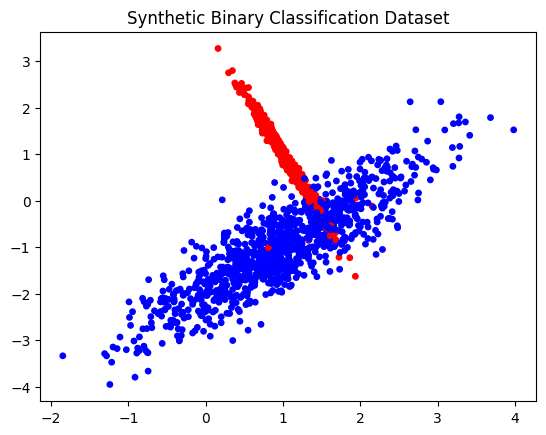

In [3]:
X, y = make_classification(
    n_samples=1500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    weights=[0.7, 0.3],   # slight imbalance
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", s=15)
plt.title("Synthetic Binary Classification Dataset")
plt.show()


### Fit logistic regression model on data

In [4]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)[:, 1]


### Plot Confusion Matrix for this classifier

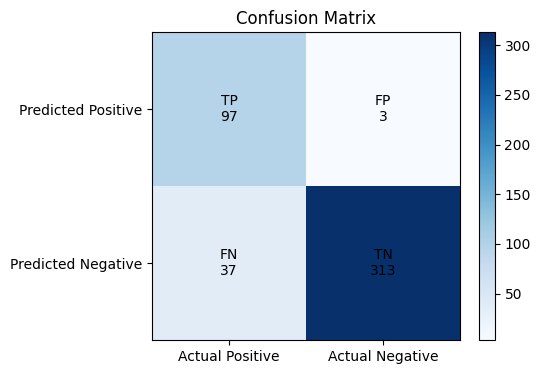

In [5]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
cm_class = np.array([
    [cm[0,0], cm[1,0]],   # Predicted Positive: TP, FP
    [cm[0,1], cm[1,1]]    # Predicted Negative: FN, TN
])

plt.figure(figsize=(5,4))
plt.imshow(cm_class, cmap="Blues")
plt.colorbar()

plt.xticks([0,1], ["Actual Positive", "Actual Negative"])
plt.yticks([0,1], ["Predicted Positive", "Predicted Negative"])

labels = np.array([
    ["TP", "FP"],
    ["FN", "TN"]
])

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{labels[i,j]}\n{cm_class[i,j]}",
                 ha="center", va="center", color="black")

plt.title("Confusion Matrix")
plt.show()

TP = int(cm_class[0,0])
FP = int(cm_class[0,1])
FN = int(cm_class[1,0])
TN = int(cm_class[1,1])


### Calculate accuracy, precision, recall and fpr for model

In [6]:
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
fpr       = FP / (FP + TN)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall\ TPR: {recall}")
print(f"FPR: {fpr}")

Accuracy: 0.9111111111111111
Precision: 0.97
Recall\ TPR: 0.7238805970149254
FPR: 0.00949367088607595


### Plot how changing the threshold effects the decision boundary and confusion matrix

In [7]:
widgets.interact(plot_confusion_and_boundary, threshold=(0.0, 1.0, 0.01))


interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.01), Output()), _dom_cla…

<function __main__.plot_confusion_and_boundary(threshold=0.5)>

TP = red points predicted as red

FP = blue points predicted as red

FN = red points predicted as blue

TN = blue points predicted as blue


In [8]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))
thresholds = np.linspace(0, 1, 60)
plt.close(fig)

HTML(animation.FuncAnimation(fig, animate, frames=len(thresholds), interval=120).to_jshtml())


### Plot ROC curve and display AUC

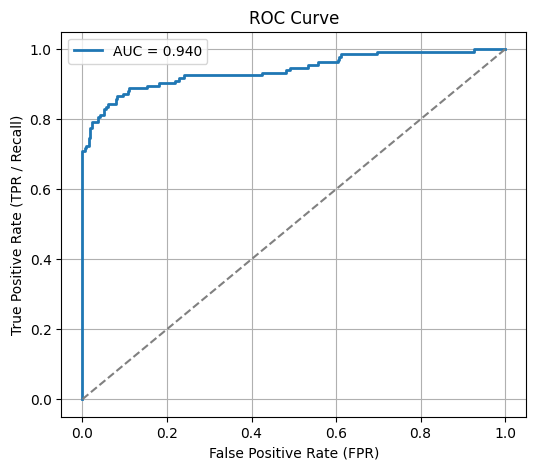

In [10]:
fpr_vals, tpr_vals, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)
plt.figure(figsize=(6,5))
plt.plot(fpr_vals, tpr_vals, linewidth=2, label=f"AUC = {auc:.3f}")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.show()


### Train a SVM model to compare

In [12]:
svm = SVC(
    kernel="sigmoid",
    C=1e-17,
    probability=True,
    random_state=42
)

# Train only on X_train (same features as logistic regression)
svm.fit(X_train, y_train)

# Predictions and score
y_pred_svm = svm.predict(X_test)
y_score_svm = svm.predict_proba(X_test)[:, 1]

# Accuracy comparison
acc_logreg = model.score(X_test, y_test)
acc_svm = svm.score(X_test, y_test)

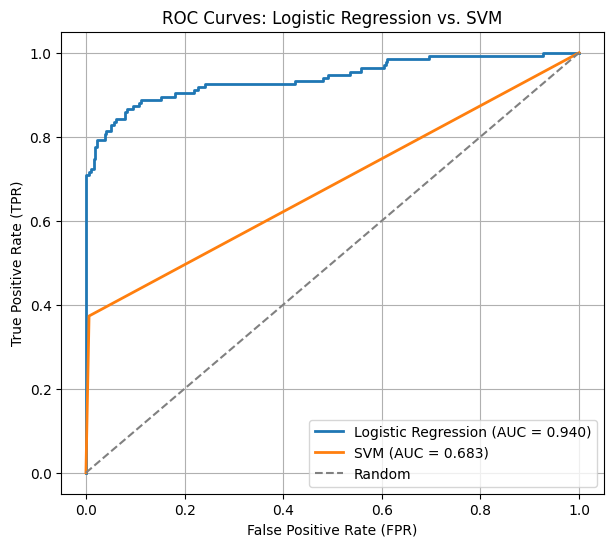

In [13]:
# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_score)
auc_log = roc_auc_score(y_test, y_score)

# Worse SVM ROC
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
auc_svm = roc_auc_score(y_test, y_score_svm)

plt.figure(figsize=(7,6))

plt.plot(fpr_log, tpr_log, linewidth=2,
         label=f"Logistic Regression (AUC = {auc_log:.3f})")

plt.plot(fpr_svm, tpr_svm, linewidth=2, linestyle="-",
         label=f"SVM (AUC = {auc_svm:.3f})")

# Random baseline
plt.plot([0,1], [0,1], "--", color="gray", label="Random")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves: Logistic Regression vs. SVM")
plt.grid(True)
plt.legend()
plt.show()


# Multiclass

### Imports

### Generate a Multiclass Dataset (4 Classes)

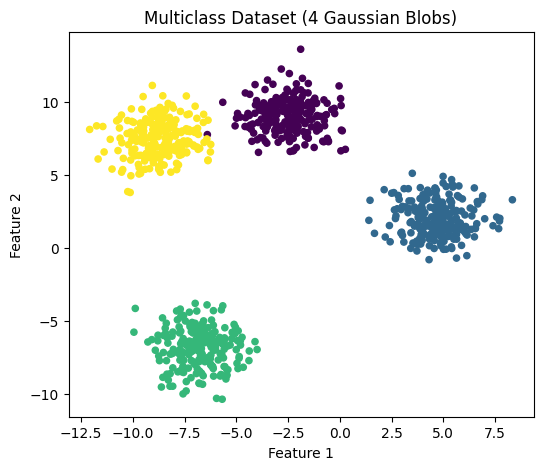

In [28]:
# Create a 4-class dataset
X, y = make_blobs(
    n_samples=900,
    n_features=2,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", s=20)
plt.title("Multiclass Dataset (4 Gaussian Blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Softmax classifier

In [22]:
from sklearn.linear_model import LogisticRegression

softmax_clf = LogisticRegression(
    C=10,
)
softmax_clf.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## One vs. All (OvA or OvR) classifier

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

ova_clf = OneVsRestClassifier(
    LogisticRegression(
        C=10,
    )
)
ova_clf.fit(X_train, y_train)


,estimator,LogisticRegression(C=10)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


## One vs. One classifier

In [24]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.svm import SVC

ovo_clf = OneVsOneClassifier(
    SVC(kernel="rbf", C=1.0, gamma="scale", probability=True)
)
ovo_clf.fit(X_train, y_train)


,estimator,SVC(probability=True)
,n_jobs,None
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200


## Print accuracies

In [26]:
acc_softmax = softmax_clf.score(X_test, y_test)
acc_ova = ova_clf.score(X_test, y_test)
acc_ovo = ovo_clf.score(X_test, y_test)

print(f"softmax accuracy: {acc_softmax:.3f}")
print(f"One vs. All accuracy: {acc_ova:.3f}")
print(f"One vs. One accuracy: {acc_ovo:.3f}")

softmax accuracy: 1.000
One vs. All accuracy: 1.000
One vs. One accuracy: 1.000


### Plot Decision Boundary for each classifier

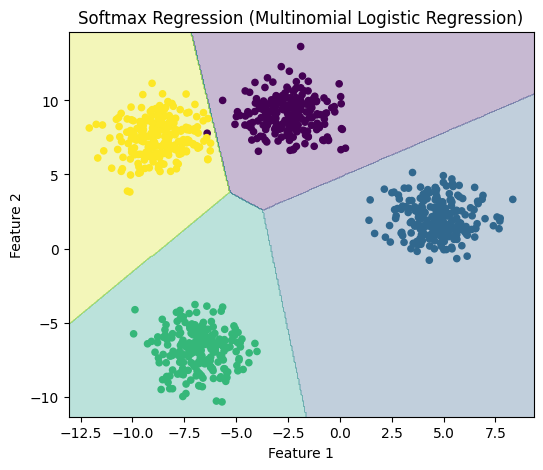

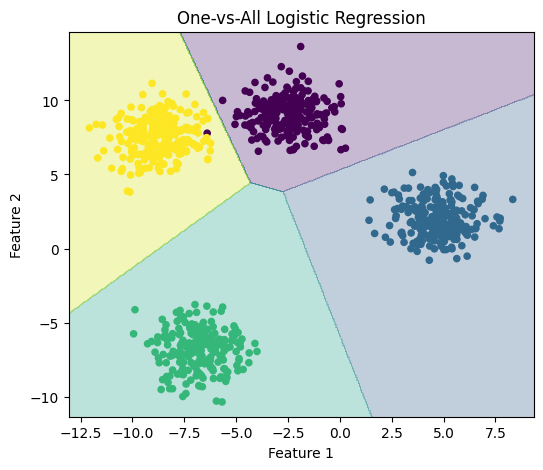

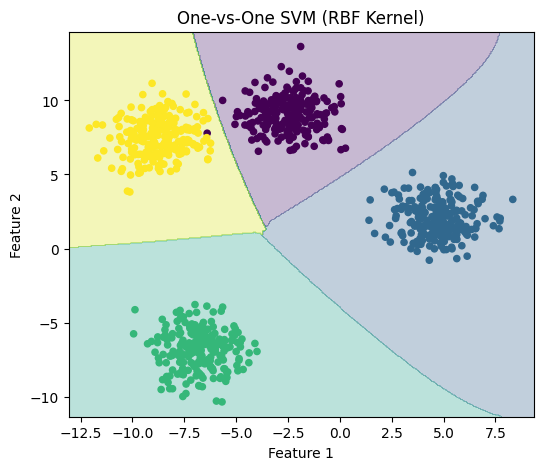

In [29]:
plot_decision_boundary(softmax_clf, X, y,
                       "Softmax Regression (Multinomial Logistic Regression)")

plot_decision_boundary(ova_clf, X, y,
                       "One-vs-All Logistic Regression")

plot_decision_boundary(ovo_clf, X, y,
                       "One-vs-One SVM (RBF Kernel)")


## A new test point


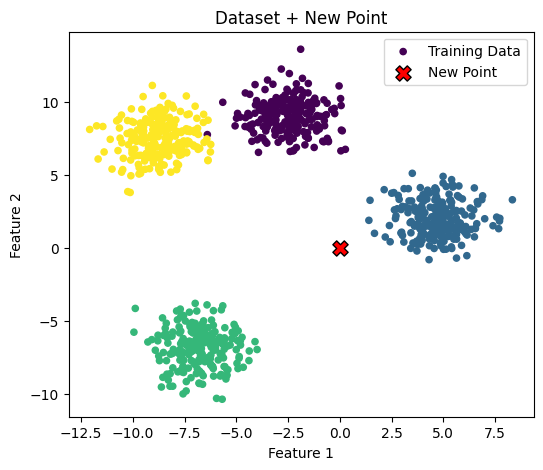

In [30]:
x_new = np.array([[0, 0]])

# Plot dataset with the new point
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", s=20, label="Training Data")
plt.scatter(x_new[:,0], x_new[:,1], c="red", s=120, edgecolor="black", marker="X", label="New Point")

plt.title("Dataset + New Point")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


In [33]:
# Softmax Regression
softmax_pred = softmax_clf.predict(x_new)[0]
softmax_probs = softmax_clf.predict_proba(x_new)[0]

# OvA Logistic Regression
ova_pred = ova_clf.predict(x_new)[0]
ova_probs = ova_clf.predict_proba(x_new)[0]

# OvO SVM
ovo_pred = ovo_clf.predict(x_new)[0]
ovo_scores = ovo_clf.decision_function(x_new)[0]

## Bar plot comparing classifier outputs for $x_{new}$

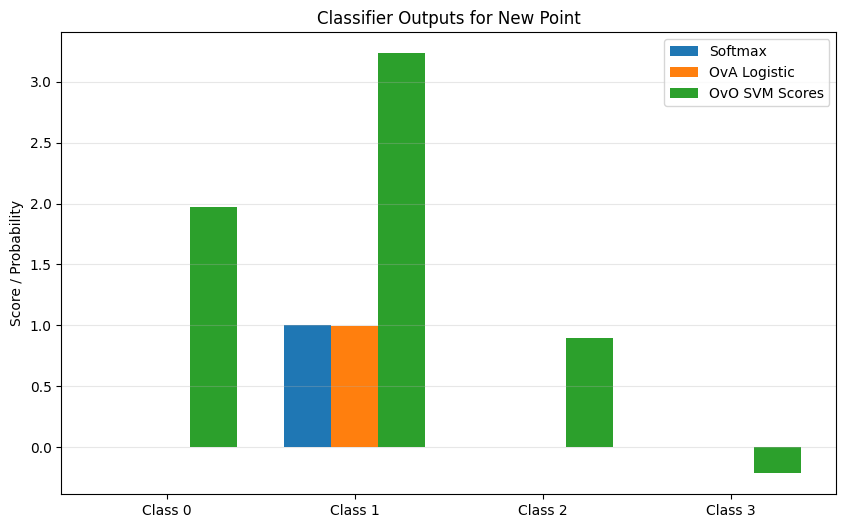

In [36]:
labels = [f"Class {i}" for i in range(len(softmax_probs))]

x = np.arange(len(labels))  # positions for bars
width = 0.25                # bar width

plt.figure(figsize=(10,6))

# Softmax probabilities
plt.bar(x - width, softmax_probs, width, label="Softmax")

# OvA probabilities
plt.bar(x, ova_probs, width, label="OvA Logistic")

# OvO scores (not probabilities!)
plt.bar(x + width, ovo_scores, width, label="OvO SVM Scores")

plt.xticks(x, labels)
plt.ylabel("Score / Probability")
plt.title("Classifier Outputs for New Point")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


In [46]:
print_scores(softmax_probs, "Softmax probs")
print_scores(ova_probs, "OvA probs")
print_scores(ovo_scores, "OvO scores")

Softmax probs
Class 0: 0.000
Class 1: 1.000
Class 2: 0.000
Class 3: 0.000
--------------------------------------------------
OvA probs
Class 0: 0.000
Class 1: 0.994
Class 2: 0.006
Class 3: 0.000
--------------------------------------------------
OvO scores
Class 0: 1.972
Class 1: 3.233
Class 2: 0.896
Class 3: -0.213
--------------------------------------------------


## Decision boundaries of each classifier with x_new plotted

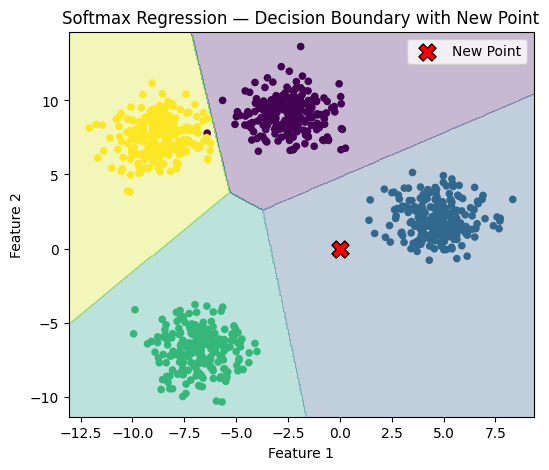

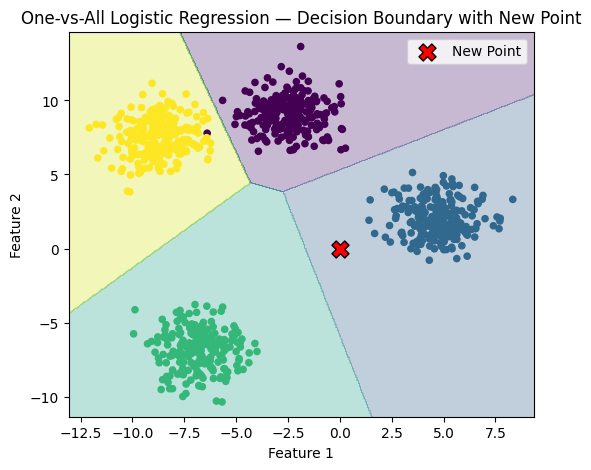

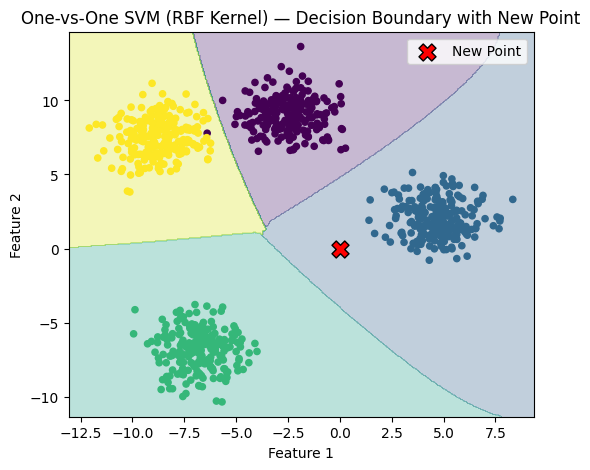

In [43]:
models = [
    (softmax_clf, "Softmax Regression"),
    (ova_clf, "One-vs-All Logistic Regression"),
    (ovo_clf, "One-vs-One SVM (RBF Kernel)")
]

for clf, title in models:
    # Create grid for decision boundary
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))

    # Decision region
    plt.contourf(xx, yy, Z, cmap="viridis", alpha=0.3)

    # Original data
    plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", s=20)

    # New point as a big X marker
    plt.scatter(x_new[:,0], x_new[:,1],
                c="red", s=150, edgecolor="black", marker="X",
                label="New Point")

    plt.title(f"{title} — Decision Boundary with New Point")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()
